In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from cns.data_utils import load_data, out_path, data_path
from cns.process.binning import mean_bins, add_seg_info

# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
data = load_data()
cna_df = add_seg_info(data["PCAWG"].cns)
samples_df = data["PCAWG"].samples
cna_df

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,SP1003,chr1,0,37828027,2,2,4,37828027,18914013,18914013
1,SP1003,chr1,37828027,38563006,2,1,3,734979,38195516,38195516
2,SP1003,chr1,38563006,39884821,2,0,2,1321815,39223913,39223913
3,SP1003,chr1,39884821,40536570,16,14,30,651749,40210695,40210695
4,SP1003,chr1,40536570,104039773,2,1,3,63503203,72288171,72288171
...,...,...,...,...,...,...,...,...,...,...
417999,SP9979,chr21,14299999,48129895,1,1,2,33829896,31214947,2812813772
418000,SP9979,chr22,0,51304566,1,1,2,51304566,25652283,2855381003
418010,SP9979,chrX,0,47375545,1,1,2,47375545,23687772,2904721058
418011,SP9979,chrX,47375545,47409735,1,0,1,34190,47392640,2928425926


In [6]:
sample_cns = cna_df.query("sample_id == 'SP1003'")
sample_cns

,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,SP1003,chr1,0,37828027,2,2,4,37828027,18914013,18914013
1,SP1003,chr1,37828027,38563006,2,1,3,734979,38195516,38195516
2,SP1003,chr1,38563006,39884821,2,0,2,1321815,39223913,39223913
3,SP1003,chr1,39884821,40536570,16,14,30,651749,40210695,40210695
4,SP1003,chr1,40536570,104039773,2,1,3,63503203,72288171,72288171
...,...,...,...,...,...,...,...,...,...,...
267,SP1003,chrX,70198063,71016601,6,0,6,818538,70607332,2951640618
268,SP1003,chrX,71016601,72840297,2,0,2,1823696,71928449,2952961735
269,SP1003,chrX,72840297,73836091,4,0,4,995794,73338194,2954371480
270,SP1003,chrX,73836091,74754999,6,0,6,918908,74295545,2955328831


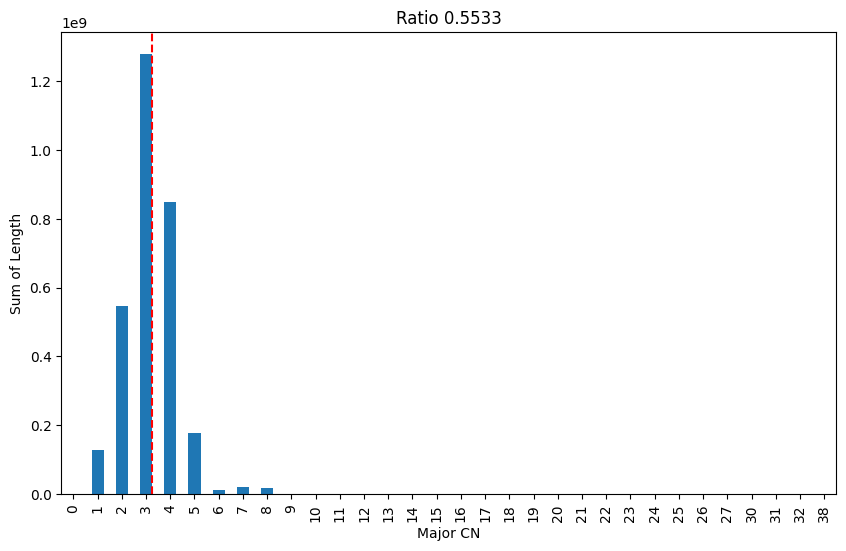

In [7]:
# Group by major_cn and sum the length
grouped = sample_cns.groupby('total_cn')['length'].sum()

# calculate weighted mean of total_cn
weighted_mean = np.average(grouped.index, weights=grouped.values)

# print a vertical line at the weighted mean
plt.axvline(x=weighted_mean, color='red', linestyle='--')

# calculate the sum of lengthgs below and above mean
below = grouped[grouped.index < weighted_mean].sum()
above = grouped[grouped.index > weighted_mean].sum()
ratio = above / below

# Create a bar plot
grouped.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Major CN')
plt.ylabel('Sum of Length')
plt.title(f'Ratio {ratio:.4f}')
plt.show()

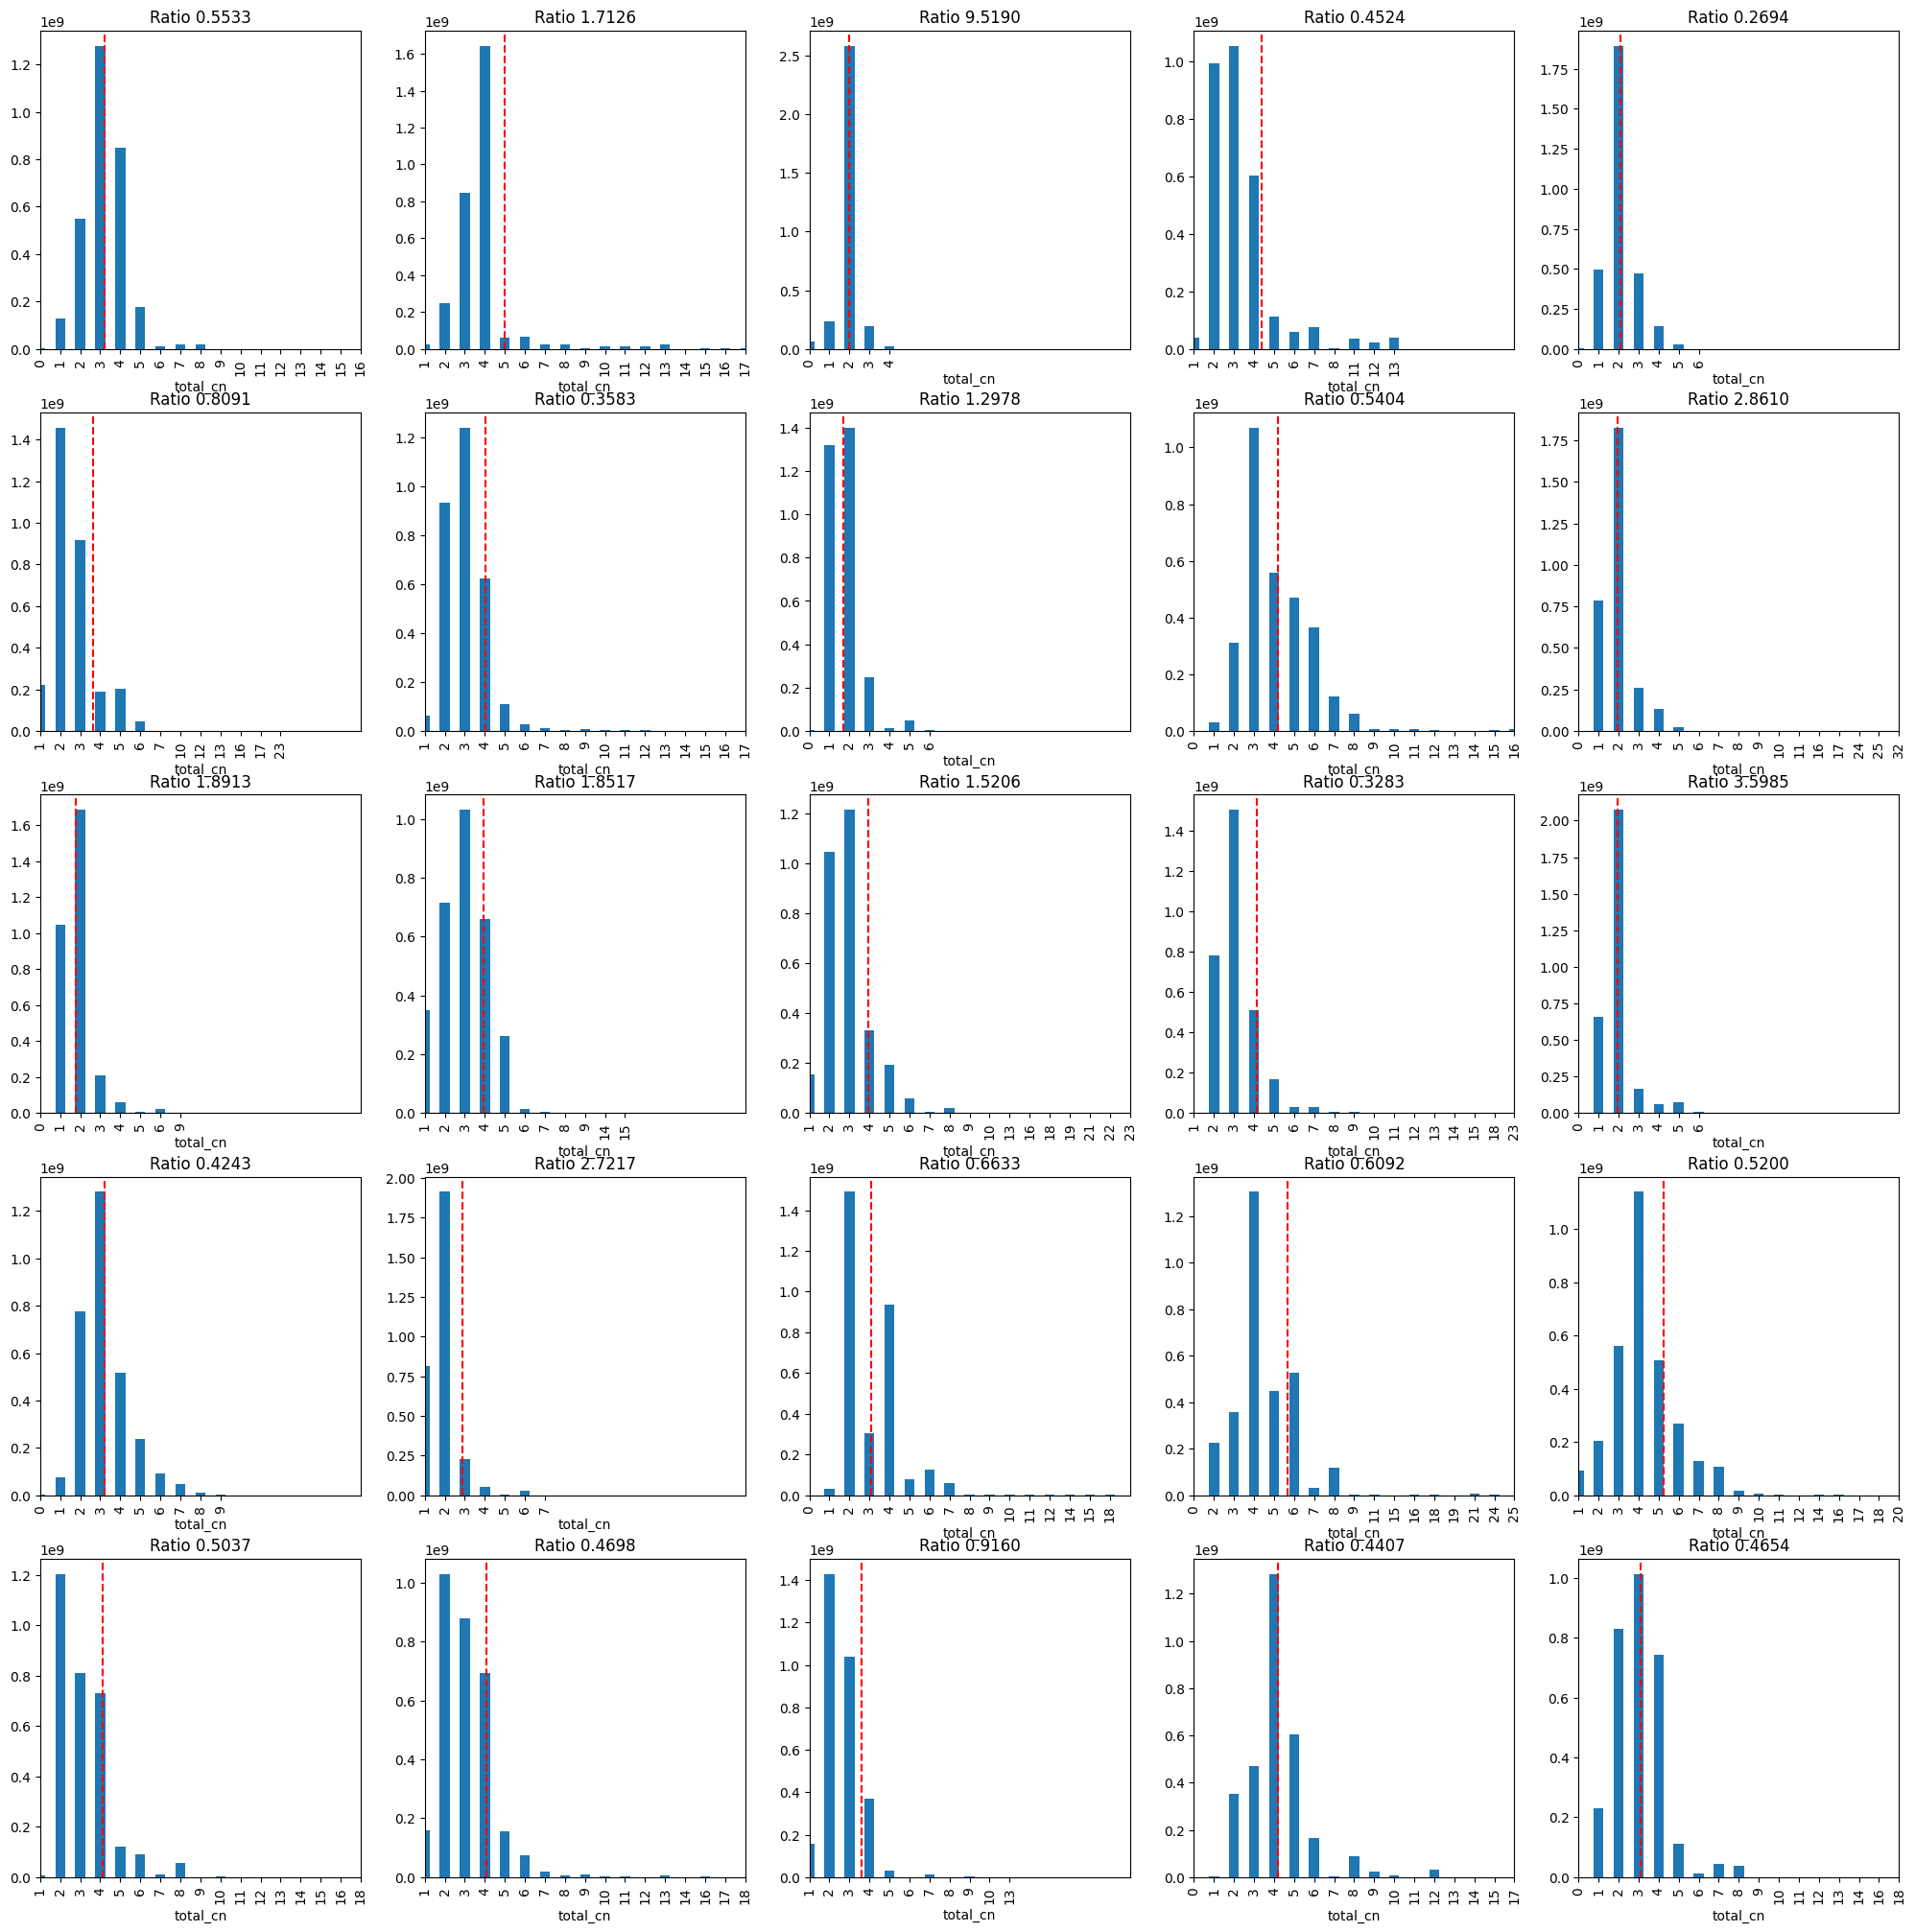

In [8]:
# create a 5 * 5 plot
fig, ax = plt.subplots(5, 5, figsize=(25, 25))

sample_ids = cna_df["sample_id"].unique().tolist()

for x in range(5):
    for y in range(5):
        sample_id = sample_ids[x * 5 + y]
        sample_cns = cna_df.query("sample_id == @sample_id")
        grouped = sample_cns.groupby('total_cn')['length'].sum()
        
        weighted_mean = np.average(grouped.index, weights=grouped.values)
        # print a vertical line at the weighted mean
        grouped.plot(kind='bar', ax=ax[x, y])

        below = grouped[grouped.index < weighted_mean].sum()
        above = grouped[grouped.index > weighted_mean].sum()
        ratio = above / below

        ax[x, y].axvline(x=weighted_mean, color='red', linestyle='--')
        ax[x, y].set_title(f'Ratio {ratio:.4f}')
        ax[x, y].set_xlim(0, 16)

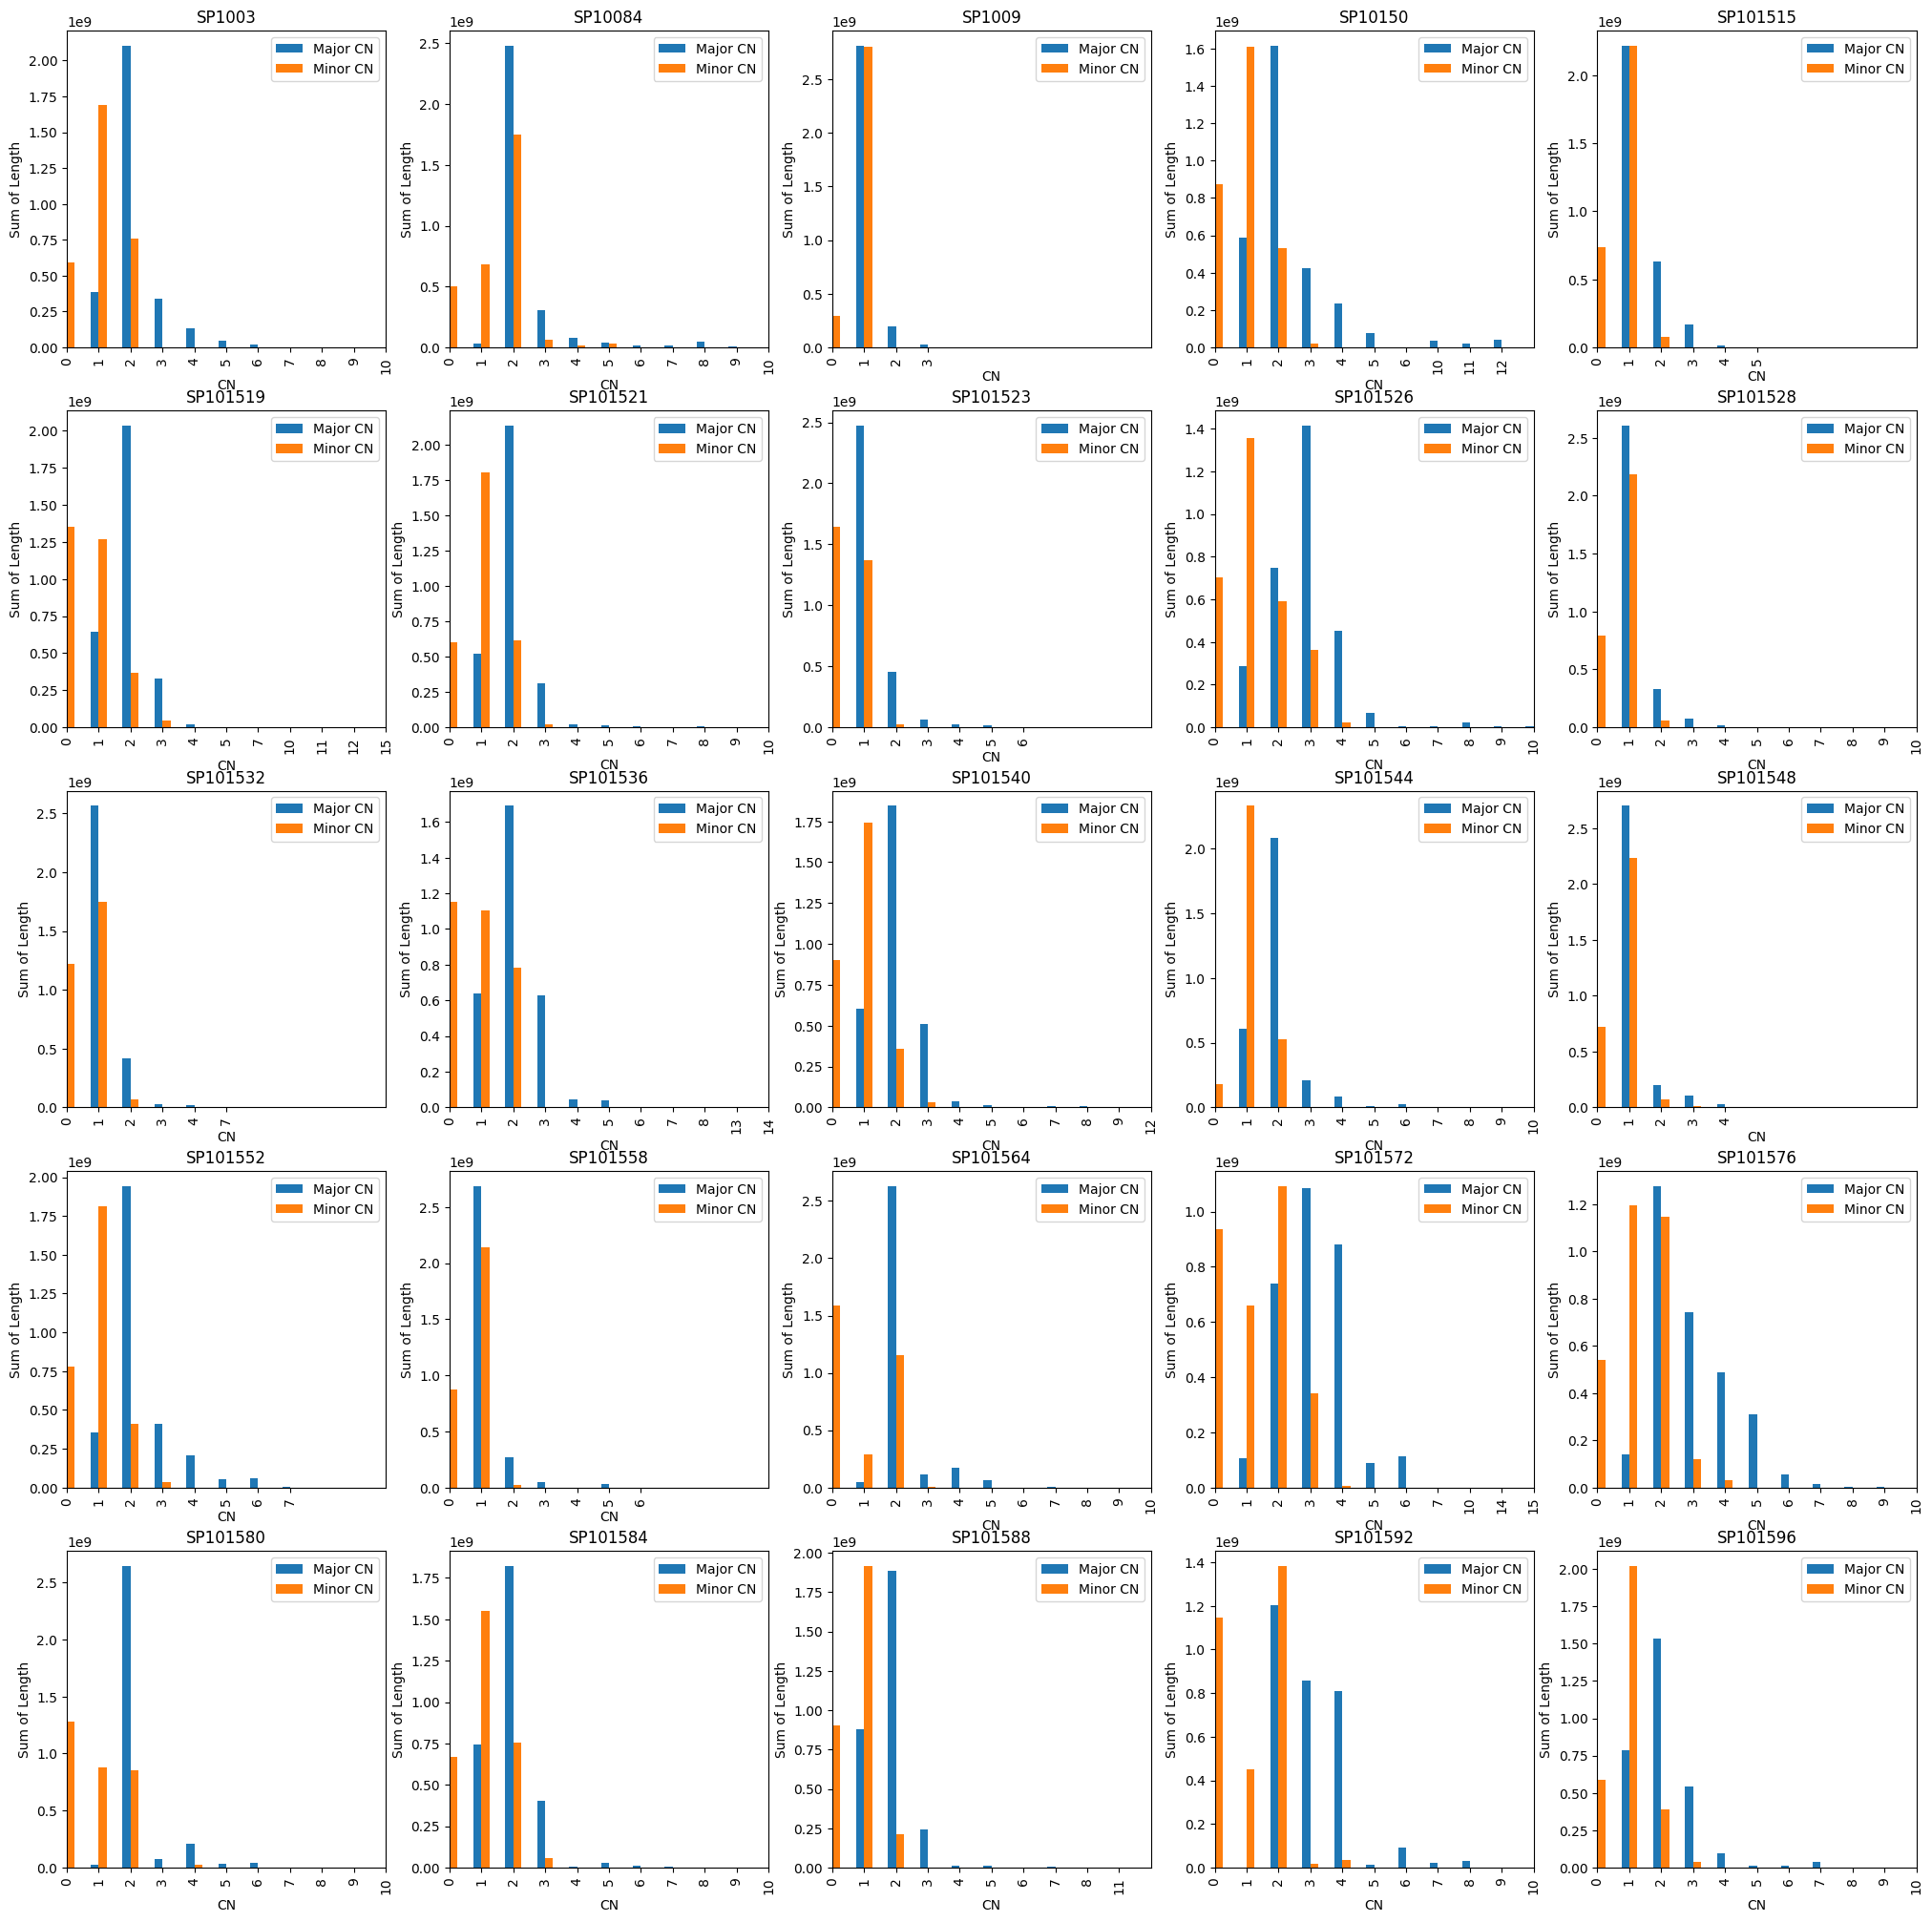

In [9]:
# create a 5 * 5 plot
fig, ax = plt.subplots(5, 5, figsize=(25, 25))

sample_ids = cna_df["sample_id"].unique().tolist()

for x in range(5):
    for y in range(5):
        sample_id = sample_ids[x * 5 + y]
        sample_cns = cna_df.query("sample_id == @sample_id")
        grouped = sample_cns.groupby('major_cn')['length'].sum()
        ax_sel = ax[x, y]

        # Group by major_cn and minor_cn and sum the length
        grouped_major = sample_cns.groupby('major_cn')['length'].sum()
        grouped_minor = sample_cns.groupby('minor_cn')['length'].sum()

        # Create a DataFrame from the grouped data
        df = pd.DataFrame({'Major CN': grouped_major, 'Minor CN': grouped_minor})

        # Fill NaN values with 0
        df.fillna(0, inplace=True)

        # Create a bar plot
        df.plot(kind='bar', ax=ax_sel)
        ax_sel.set_xlim(0, 10)

        ax_sel.set_xlabel('CN')
        ax_sel.set_ylabel('Sum of Length')
        ax_sel.set_title(sample_id)